# 03 · Segmentação de clientes
**PP1:** que perfis emergem dos atributos e como se relacionam com churn?

KMeans e transformações são ajustados somente no treino definido no notebook 02. O alvo não entra nas distâncias nem na escolha de k. Comparamos k=2…10 pela silhueta; o cotovelo é uma evidência complementar (pode não ser nítido). A escolha automática maximiza a silhueta no treino, com desempate pelo menor k. PCA serve apenas à visualização. Churn será consultado após fixar os grupos. Os clusters não são adicionados à classificação.

Usamos os 12 preditores preparados no notebook 02: numéricos padronizados e binários 0/1. Distâncias dependem dessa escolha; variáveis correlacionadas podem ter peso redundante. Não aplicamos balanceamento na segmentação.

In [1]:
from pathlib import Path
import sys, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/common.py').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.common import *
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.spines.top': False, 'axes.spines.right': False})
df, X, y, groups, tr, te = load_data()
X_train, X_test = X.iloc[tr], X.iloc[te]
y_train, y_test = y.iloc[tr], y.iloc[te]
for directory in ['reports/figuras', 'reports/tabelas', 'reports/dashboards', 'models']:
    (ROOT / directory).mkdir(parents=True, exist_ok=True)


k escolhido por silhueta: 3


,k,inercia,silhueta
0,1,23473.7406,NaN
1,2,17087.8437,0.3042
2,3,13872.2601,0.3061
3,4,12467.8201,0.2039
4,5,11173.6193,0.2649
5,6,10031.2414,0.2346
6,7,9045.2974,0.2534
7,8,8333.1961,0.2514
8,9,7658.4398,0.2531
9,10,7196.7892,0.2510


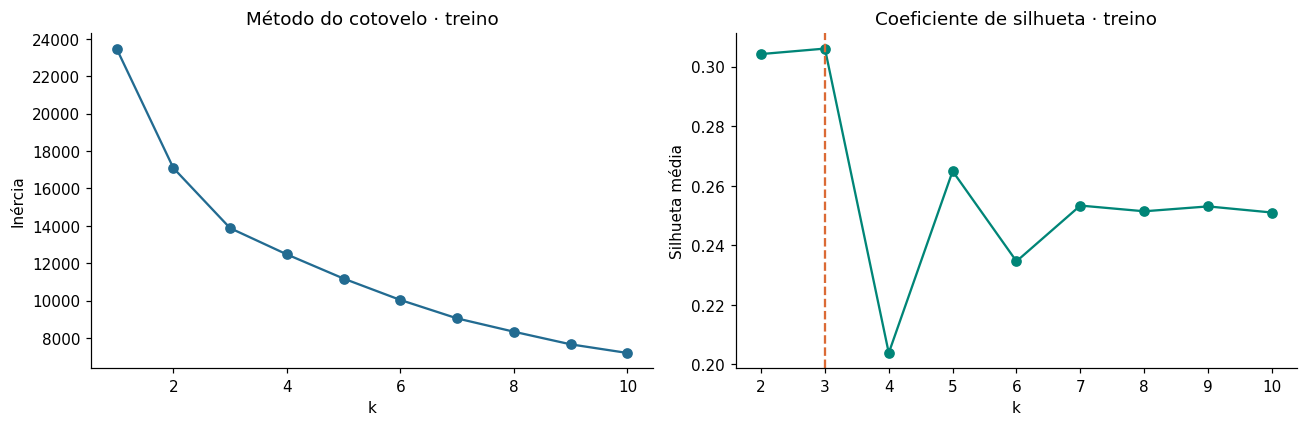

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import joblib
prep = preprocessor(X)
Z = prep.fit_transform(X_train)
Ztest = prep.transform(X_test)
rows, candidates = [], {}
for k in range(1, 11):
    model = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit(Z)
    candidates[k] = model
    rows.append({'k': k, 'inercia': model.inertia_,
                 'silhueta': silhouette_score(Z, model.labels_) if k > 1 else np.nan})
quality = pd.DataFrame(rows)
k_best = int(quality.dropna().sort_values(['silhueta','k'], ascending=[False,True]).iloc[0].k)
km = candidates[k_best]
display(quality.round(4))
print('k escolhido por silhueta:', k_best)
quality.to_csv(ROOT / 'reports/tabelas/cluster_qualidade.csv', index=False)
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(quality.k, quality.inercia, 'o-', color='#226B91')
ax[0].set(title='Método do cotovelo · treino', xlabel='k', ylabel='Inércia')
ax[1].plot(quality.k, quality.silhueta, 'o-', color='#008577')
ax[1].axvline(k_best, color='#DB6A35', linestyle='--')
ax[1].set(title='Coeficiente de silhueta · treino', xlabel='k', ylabel='Silhueta média')
savefig(fig, 'cluster_cotovelo_silhueta')
plt.show()

## Perfis e projeção
Os nomes dos grupos são identificadores arbitrários. As taxas de churn são descritivas; não demonstram causalidade nem validam uma campanha de retenção.

Out[0]: 173


clientes  churns  taxa_churn
conjunto cluster                              
teste    0             116       2    0.017241
         1             382      97    0.253927
         2             135       1    0.007407
treino   0             459       3    0.006536
         1            1493     389    0.260549
         2             565       3    0.005310

,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,tariff_plan,status,age,customer_value
cluster,,,,,,,,,,,,
0,5.25,0.02,32.60,1.03,4256.45,65.20,277.83,22.47,0.21,0.00,28.52,1319.19
1,5.58,0.11,32.29,0.40,2230.88,40.25,15.28,16.57,0.01,0.42,30.88,148.28
2,15.06,0.03,33.17,2.31,10654.14,151.19,60.13,42.95,0.16,0.00,33.35,638.57


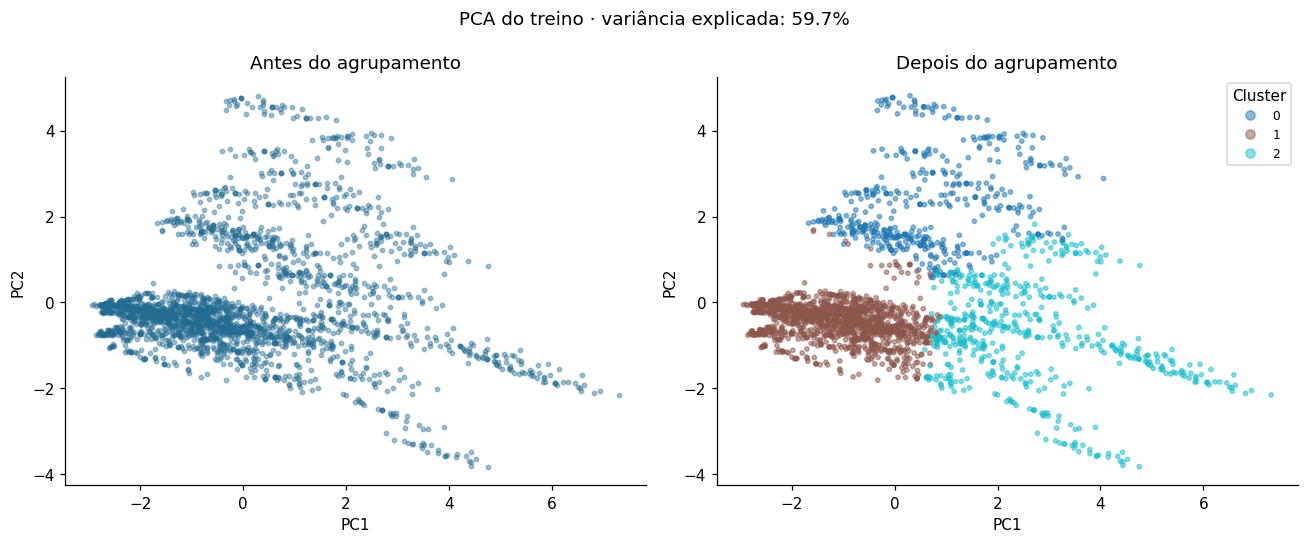

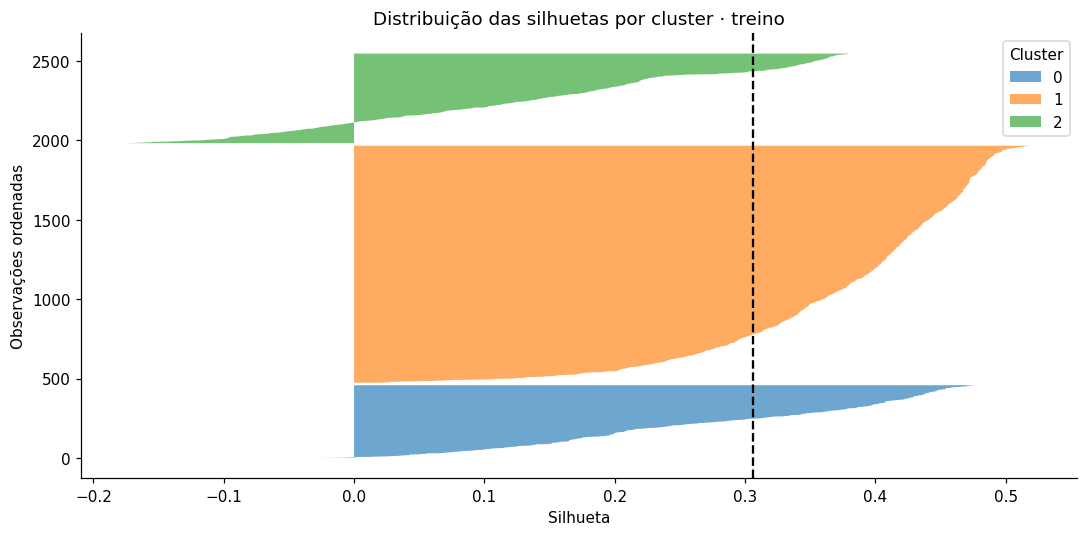

In [3]:
labels = km.predict(prep.transform(X))
profiles = X.copy()
profiles['cluster'], profiles['churn'] = labels, y
profiles['conjunto'] = np.where(np.isin(np.arange(len(X)), tr), 'treino', 'teste')
profiles.index.name = 'row_id'
profiles.to_csv(ROOT / 'reports/tabelas/clientes_clusters.csv')
summary = profiles.groupby(['conjunto','cluster']).agg(clientes=('churn','size'), churns=('churn','sum'), taxa_churn=('churn','mean'))
summary.to_csv(ROOT / 'reports/tabelas/cluster_resumo.csv')
means = profiles.groupby('cluster')[X.columns].mean()
means.to_csv(ROOT / 'reports/tabelas/cluster_perfis_medias.csv')
display(summary)
display(means.round(2))
pca = PCA(n_components=2, random_state=SEED).fit(Z)
points = pca.transform(Z)
fig, axes = plt.subplots(1,2,figsize=(12,5))
axes[0].scatter(points[:,0], points[:,1], s=8, alpha=.4, color='#226B91')
scatter = axes[1].scatter(points[:,0], points[:,1], c=km.labels_, cmap='tab10', s=8, alpha=.5)
axes[1].legend(*scatter.legend_elements(), title='Cluster', fontsize=8)
for ax, title in zip(axes,['Antes do agrupamento','Depois do agrupamento']):
    ax.set(title=title, xlabel='PC1', ylabel='PC2')
fig.suptitle(f'PCA do treino · variância explicada: {pca.explained_variance_ratio_.sum():.1%}')
savefig(fig, 'cluster_pca')
plt.show()
pd.DataFrame({'PC1': points[:,0], 'PC2': points[:,1], 'cluster': km.labels_}).to_csv(ROOT/'reports/tabelas/cluster_pca.csv', index=False)
fig, ax = plt.subplots()
sil = silhouette_samples(Z, km.labels_)
ypos = 0
for cluster in range(k_best):
    values = np.sort(sil[km.labels_ == cluster])
    ax.fill_betweenx(np.arange(ypos,ypos+len(values)), 0, values, alpha=.65, label=str(cluster))
    ypos += len(values)+15
ax.axvline(sil.mean(), linestyle='--', color='black')
ax.set(title='Distribuição das silhuetas por cluster · treino', xlabel='Silhueta', ylabel='Observações ordenadas')
ax.legend(title='Cluster')
savefig(fig, 'cluster_silhuetas')
plt.show()
joblib.dump({'preprocessor':prep, 'kmeans':km, 'pca':pca}, ROOT/'models/clusterizacao.joblib')
(ROOT/'reports/tabelas/cluster_metadata.json').write_text(json.dumps({'k':k_best, 'silhueta_treino':float(sil.mean()), 'pca_variancia':float(pca.explained_variance_ratio_.sum()), 'sha256':fingerprint()}, indent=2))